# Fast Kurtogram

The **spectral kurtosis** (SK) of a band-pass filtered record is the
kurtosis of its complex envelope. A transient (bearing knock, gear
tooth crack, repetitive impulse buried in stationary noise) is
*most detectable* in a specific band $(f_c,\Delta f)$: too wide and
the noise wins, too narrow and the impulse is smeared. Scanning every
centre frequency and bandwidth with a sliding STFT is accurate but $O(N^2)$.

Antoni's **fast kurtogram** (MSSP 2007) replaces that grid with a
**1/2-binary + 1/3-ternary** analytic FIR tree. Each node is a complex
envelope whose kurtosis is one pixel of a 2-D map — the kurtogram —
versus frequency and decomposition level $k$, where the bandwidth is

$
\Delta f = F_s / 2^{k+1}.
$

The tree costs $O(N\log N)$. The peak of the map is the band that
should be demodulated.

This notebook ports MATLAB `Fast_kurtogram.m` (Pack Kurtogram V4).
The MATLAB driver always plots and then blocks on `input()` to filter.
PySDKit is non-interactive: `fast_kurtogram` returns the map; an
explicit `find_wav_kurt` extracts the envelope.

| | **STFT SK** | **Fast kurtogram** (this notebook) |
|---|---|---|
| Band tiling | uniform $(f,\Delta f)$ grid | dyadic / 1/3-binary tree |
| Cost | $O(N^2)$ exhaustive | $O(N\log N)$ filter bank |
| Output | SK vs frequency at one $\Delta f$ | 2-D map vs $f_c$ and level $k$ |
| Filtering | user-designed band-pass | packet path at the peak dyad |

**Reference**

> J. Antoni, *Fast computation of the kurtogram for the detection of
> transient faults*, Mechanical Systems and Signal Processing 21 (2007)
> 108–124.

MATLAB: `repo/Pack Kurtogram V4/Fast_kurtogram.m`, `demo_Fast_Kurtogram.m`.


## 1. Imports


In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit.data import load_fast_kurtogram_x
from pysdkit.utils import (
    fast_kurtogram,
    find_wav_kurt,
    plot_kurtogram,
    prewhiten_ar,
)

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py


## 2. What the code computes

1. Demean $x$.
2. Build a short analytic low-pass / high-pass pair $(h,g)$
   (`fir1` order 16, modulated to $1/8$ Nyquist) and a length-24
   ternary trio $(h_1,h_2,h_3)$.
3. Recurse a wavelet-packet tree: **binary** split at every level,
   plus a **ternary** split of each node (the extra rows of the map).
4. Score $E[|c|^4]/E[|c|^2]^2-2$ of the complex envelope at each
   node (MATLAB `kurt2`); clip negative values.
5. The peak gives $K_{\max}$, level $k$, centre $f_c$ and
   bandwidth $\Delta f = F_s/2^{k+1}$.


## 3. Demo (`demo_Fast_Kurtogram.m`)

The packaged record is MATLAB `x.mat`: weak **repetitive transients**
hidden in stationary noise. Their theoretical spectral content is the
normalised band **$[0.15, 0.19]$** with $F_s=1$. Decomposition
depth `nlevel = 7`.


N = 49900   Fs = 1.0


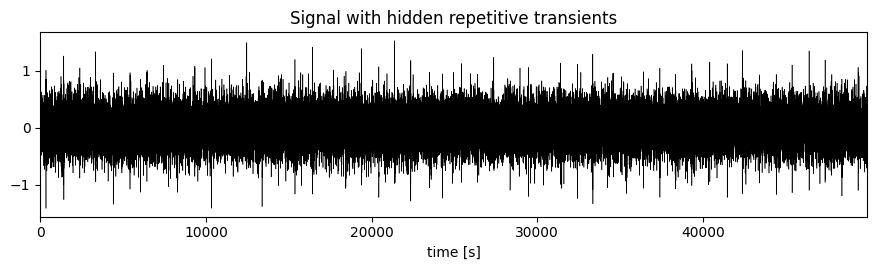

In [ ]:
demo = load_fast_kurtogram_x()
x = demo["signal"]
fs = float(demo["fs"])
t = demo["t"]
print("N =", x.size, "  Fs =", fs)

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t, x, color="k", lw=0.4)
ax.set_title("Signal with hidden repetitive transients")
ax.set_xlabel("time [s]")
ax.set_xlim(t[0], t[-1])
fig.tight_layout()

Kwav shape: (14, 384)
K_max = 6.149
level = 4.000
fc    = 0.171875 Hz
Bw    = 0.031250 Hz
peak in [0.15, 0.19]? True


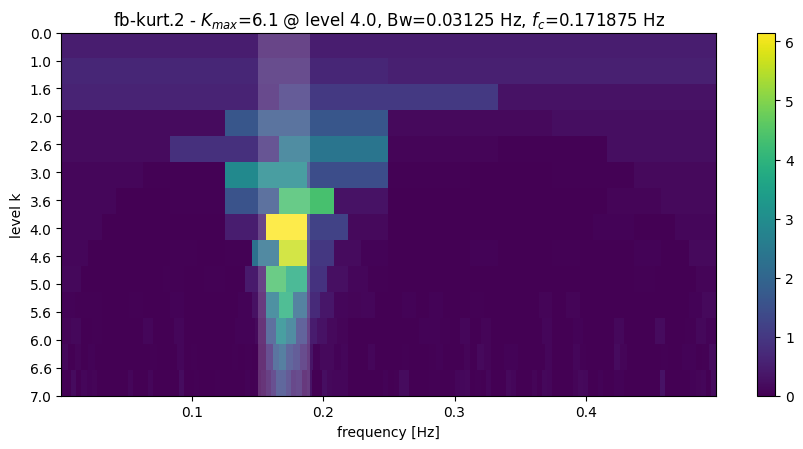

In [ ]:
nlevel = 7
Kwav, info = fast_kurtogram(x, nlevel, fs=fs)

print("Kwav shape:", Kwav.shape)
print("K_max = {:.3f}".format(info["Kmax"]))
print("level = {:.3f}".format(info["level"]))
print("fc    = {:.6f} Hz".format(info["fc"]))
print("Bw    = {:.6f} Hz".format(info["bw"]))
print("peak in [0.15, 0.19]?", 0.15 <= info["fc"] <= 0.19)

fig, ax = plt.subplots(figsize=(9, 4.6))
plot_kurtogram(Kwav, info, ax=ax)
ax.axvspan(0.15, 0.19, color="white", alpha=0.18, lw=0)
fig.tight_layout()

The white band marks the theoretical interval $[0.15, 0.19]$. The
kurtogram peak sits inside it: the tree recovered the hidden transients
without being told the band.


## 4. Optional AR pre-whitening

The MATLAB demo can inverse-filter an order-100 AR model of $x$
before the kurtogram (always helpful in detection: it flattens the
stationary spectrum so SK sees the transients rather than resonances).
The first `order` samples of the whitening transient **must** be
dropped, otherwise SK locks onto the FIR start-up.


whitened length 49800
whitened K_max = 6.146 @ fc = 0.171875 Hz, level 4.000


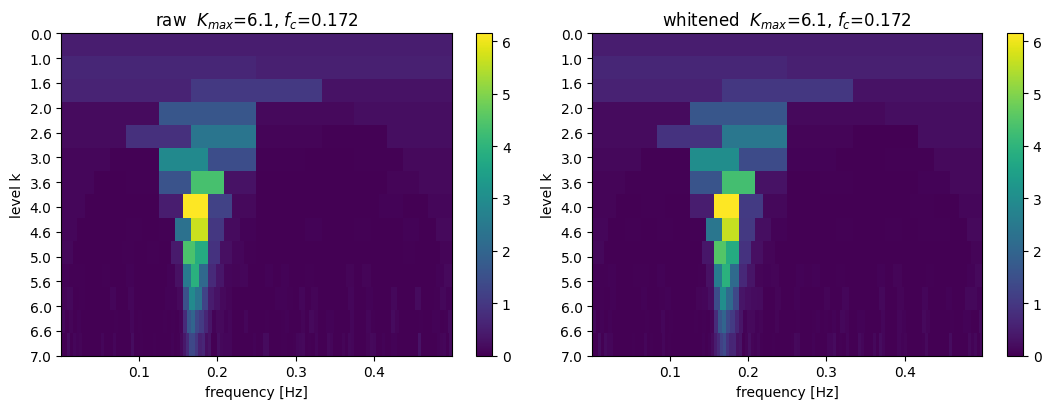

In [ ]:
x_w = prewhiten_ar(x, order=100)
K_w, info_w = fast_kurtogram(x_w, nlevel, fs=fs)
print("whitened length", x_w.size)
print(
    "whitened K_max = {:.3f} @ fc = {:.6f} Hz, level {:.3f}".format(
        info_w["Kmax"], info_w["fc"], info_w["level"]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_kurtogram(Kwav, info, ax=axes[0])
axes[0].set_title(
    "raw  $K_{{max}}$={:.1f}, $f_c$={:.3f}".format(info["Kmax"], info["fc"])
)
plot_kurtogram(K_w, info_w, ax=axes[1])
axes[1].set_title(
    "whitened  $K_{{max}}$={:.1f}, $f_c$={:.3f}".format(info_w["Kmax"], info_w["fc"])
)
fig.tight_layout()

## 5. Complex envelope at the peak

`find_wav_kurt` walks the same binary / ternary path and returns the
complex envelope $c[n]$ (MATLAB `Find_wav_kurt`, without the
`input()` prompt). The squared-envelope spectrum is the usual
demodulation check for repetition frequency.


envelope length 3103   kurtosis 6.149


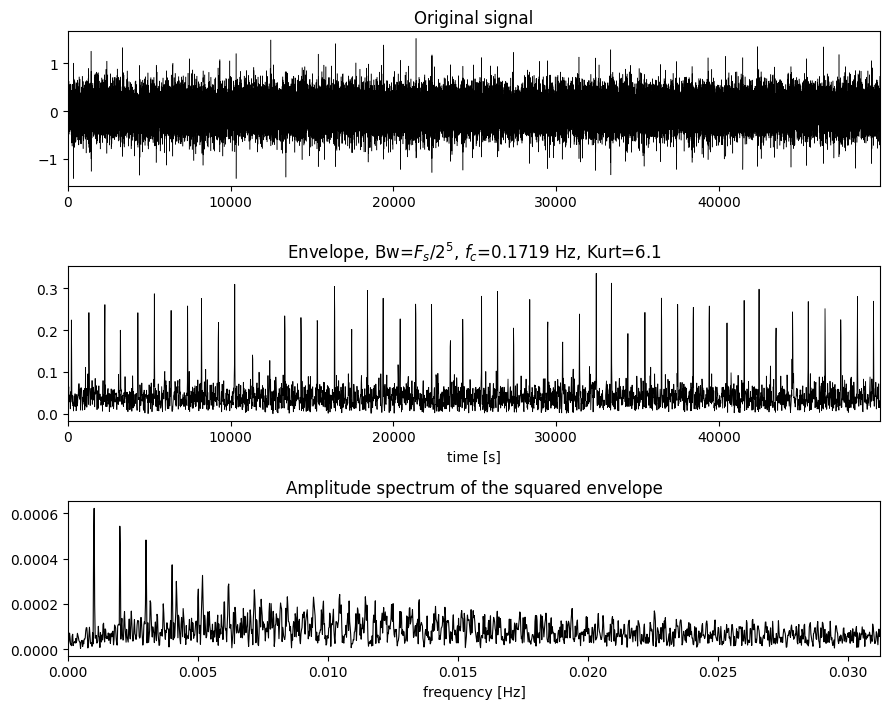

In [ ]:
fr = float(info["fc"]) / fs
out = find_wav_kurt(
    np.asarray(info["x"]), float(info["level"]), fr, fs=fs, filters=info["filters"]
)
c = np.asarray(out["c"])
print("envelope length", c.size, "  kurtosis", round(float(out["kurtosis"]), 3))

nfft = 2 * int(np.ceil(c.size / 2.0))
env = np.abs(c) ** 2
window = np.hanning(env.size)
spec = np.abs(np.fft.fft((env - env.mean()) * window / env.size, n=nfft))
level = float(out["level"])
freq_env = np.linspace(0.0, 0.5 * fs / (2.0**level), nfft // 2, endpoint=True)

tc = np.linspace(t[0], t[-1], c.size)
fig, axes = plt.subplots(3, 1, figsize=(9, 7.2), sharex=False)
axes[0].plot(t, x, color="k", lw=0.35)
axes[0].set_title("Original signal")
axes[0].set_xlim(t[0], t[-1])
axes[1].plot(tc, np.abs(c), color="k", lw=0.6)
axes[1].set_title(
    r"Envelope, Bw=$F_s/2^{{{:.0f}}}$, $f_c$={:.4f} Hz, Kurt={:.1f}".format(
        level + 1.0, float(out["fc"]), float(out["kurtosis"])
    )
)
axes[1].set_xlim(tc[0], tc[-1])
axes[1].set_xlabel("time [s]")
axes[2].plot(freq_env, spec[: nfft // 2], color="k", lw=0.8)
axes[2].set_title("Amplitude spectrum of the squared envelope")
axes[2].set_xlabel("frequency [Hz]")
axes[2].set_xlim(freq_env[0], freq_env[-1])
fig.tight_layout()